In [71]:
import pandas as pd

df = pd.read_csv("train.csv")
print(df.head())

   ID             datetime  temperature  var1  pressure  windspeed var2  \
0   0  2013-07-01 00:00:00        -11.4 -17.1    1003.0    571.910    A   
1   1  2013-07-01 01:00:00        -12.1 -19.3     996.0    575.040    A   
2   2  2013-07-01 02:00:00        -12.9 -20.0    1000.0    578.435    A   
3   3  2013-07-01 03:00:00        -11.4 -17.1     995.0    582.580    A   
4   4  2013-07-01 04:00:00        -11.4 -19.3    1005.0    586.600    A   

   electricity_consumption  
0                    216.0  
1                    210.0  
2                    225.0  
3                    216.0  
4                    222.0  


In [72]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       26496 non-null  int64  
 1   datetime                 26496 non-null  object 
 2   temperature              26496 non-null  float64
 3   var1                     26496 non-null  float64
 4   pressure                 26496 non-null  float64
 5   windspeed                26496 non-null  float64
 6   var2                     26496 non-null  object 
 7   electricity_consumption  26496 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 1.6+ MB
None
                 ID   temperature          var1      pressure     windspeed  \
count  26496.000000  26496.000000  26496.000000  26496.000000  26496.000000   
mean   17455.500000      5.098989     -1.916233    986.450615     23.959956   
std    10122.873673      8.682860     10.424860 

In [73]:
df['datetime'] = pd.to_datetime(df['datetime'])

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month

print(df.head())

   ID            datetime  temperature  var1  pressure  windspeed var2  \
0   0 2013-07-01 00:00:00        -11.4 -17.1    1003.0    571.910    A   
1   1 2013-07-01 01:00:00        -12.1 -19.3     996.0    575.040    A   
2   2 2013-07-01 02:00:00        -12.9 -20.0    1000.0    578.435    A   
3   3 2013-07-01 03:00:00        -11.4 -17.1     995.0    582.580    A   
4   4 2013-07-01 04:00:00        -11.4 -19.3    1005.0    586.600    A   

   electricity_consumption  hour  day  month  
0                    216.0     0    1      7  
1                    210.0     1    1      7  
2                    225.0     2    1      7  
3                    216.0     3    1      7  
4                    222.0     4    1      7  


In [74]:
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

ID                         0
datetime                   0
temperature                0
var1                       0
pressure                   0
windspeed                  0
var2                       0
electricity_consumption    0
hour                       0
day                        0
month                      0
dtype: int64


In [75]:
hourly_usage = df.groupby('hour')['electricity_consumption'].mean()
monthly_usage = df.groupby('month')['electricity_consumption'].sum()
category_usage = df.groupby('var2')['electricity_consumption'].mean()

print(hourly_usage.head())

hour
0    313.380435
1    314.480978
2    311.877717
3    309.260870
4    304.277174
Name: electricity_consumption, dtype: float64


In [76]:
df.to_csv("cleaned_data.csv", index=False)
hourly_usage.to_csv("hourly_usage.csv")
monthly_usage.to_csv("monthly_usage.csv")
category_usage.to_csv("category_usage.csv")

print("Data saved successfully!")

Data saved successfully!


In [77]:
print("Peak Hour:", hourly_usage.idxmax())
print("Highest Consumption Month:", monthly_usage.idxmax())
print("Top Category:", category_usage.idxmax())

Peak Hour: 1
Highest Consumption Month: 8
Top Category: B


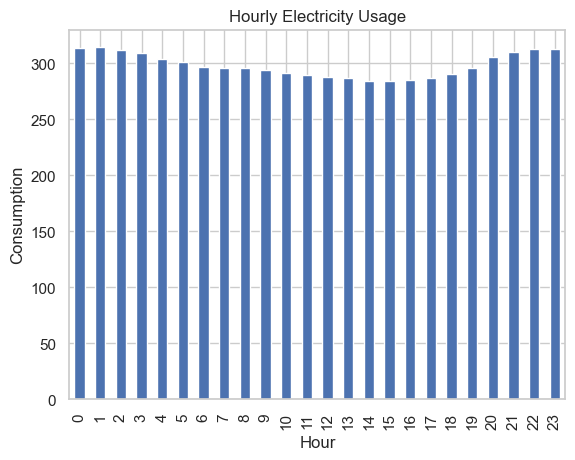

In [78]:
import matplotlib.pyplot as plt

hourly_usage.plot(kind='bar', title='Hourly Electricity Usage')
plt.xlabel("Hour")
plt.ylabel("Consumption")
plt.show()

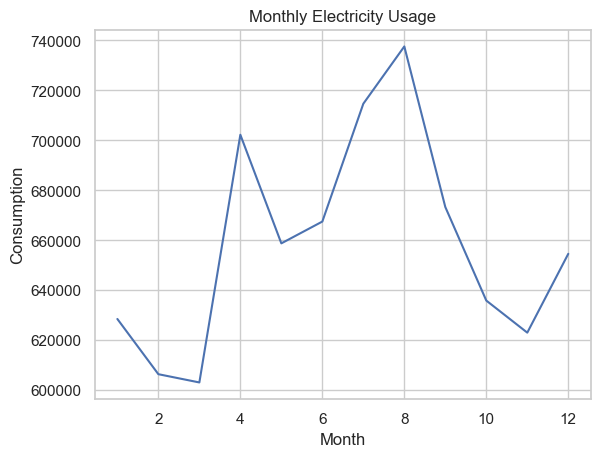

In [79]:
monthly_usage.plot(kind='line', title='Monthly Electricity Usage')
plt.xlabel("Month")
plt.ylabel("Consumption")
plt.show()

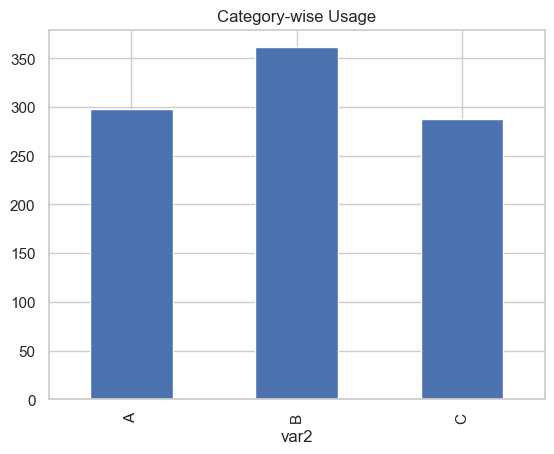

In [80]:
category_usage.plot(kind='bar', title='Category-wise Usage')
plt.show()

In [81]:
### Insights

##- Electricity consumption varies across different hours of the day.
##- Certain months show higher energy usage.
##- Some categories (var2) consume more electricity.

##This analysis helps improve transparency and encourages energy conservation.

In [82]:
print("Final Data Shape:", df.shape)
print("\nAny Missing Values?")
print(df.isnull().sum())

Final Data Shape: (26496, 11)

Any Missing Values?
ID                         0
datetime                   0
temperature                0
var1                       0
pressure                   0
windspeed                  0
var2                       0
electricity_consumption    0
hour                       0
day                        0
month                      0
dtype: int64


In [83]:
print(df.dtypes)

ID                                  int64
datetime                   datetime64[ns]
temperature                       float64
var1                              float64
pressure                          float64
windspeed                         float64
var2                               object
electricity_consumption           float64
hour                                int32
day                                 int32
month                               int32
dtype: object


In [84]:
print(df['electricity_consumption'].describe())

count    26496.000000
mean       298.359601
std        108.020555
min        174.000000
25%        219.000000
50%        267.000000
75%        342.000000
max       1386.000000
Name: electricity_consumption, dtype: float64


In [85]:
### Data Handling Summary

##- Converted datetime and extracted features (hour, day, month)
##- Removed duplicates and handled missing values
##- Created aggregated datasets for analysis
##- Validated data for consistency and accuracy

##This ensures reliable data for visualization and modeling.

In [86]:
print("Final shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

Final shape: (26496, 11)

Missing values:
 ID                         0
datetime                   0
temperature                0
var1                       0
pressure                   0
windspeed                  0
var2                       0
electricity_consumption    0
hour                       0
day                        0
month                      0
dtype: int64


In [87]:
print(df['hour'].unique())
print(df['month'].unique())

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[ 7  8  9 10 11 12  1  2  3  4  5  6]


In [88]:
### Data Handling Summary

##- Loaded raw dataset
##- Cleaned and removed duplicates
##- Extracted time-based features (hour, day, month)
##- Created aggregated datasets for analysis
##- Validated data for consistency

##Prepared data for visualization and modeling.

In [89]:
df.columns = df.columns.str.lower()

In [90]:
### Apartment Data Transformation

##The dataset is adapted to simulate apartment-level electricity usage by introducing apartment identifiers and mapping categories to apartment types.

In [91]:
df.rename(columns={'var2': 'apartment_type'}, inplace=True)

In [92]:
df['apartment_id'] = 'A' + (df.index % 50).astype(str)

In [93]:
df = df[['apartment_id', 'apartment_type', 'datetime', 
         'temperature', 'pressure', 'windspeed', 
         'electricity_consumption', 'hour', 'day', 'month']]

In [94]:
apartment_usage = df.groupby('apartment_id')['electricity_consumption'].sum()
type_usage = df.groupby('apartment_type')['electricity_consumption'].mean()

In [95]:
# Show output
print("Apartment Usage:")
print(apartment_usage.head())

print("\nType Usage:")
print(type_usage.head())

# Save files (keep this)
df.to_csv("apartment_energy_data.csv", index=False)
apartment_usage.to_csv("apartment_usage.csv")
type_usage.to_csv("type_usage.csv")

Apartment Usage:
apartment_id
A0     157296.0
A1     158778.0
A10    158361.0
A11    157620.0
A12    157458.0
Name: electricity_consumption, dtype: float64

Type Usage:
apartment_type
A    298.245453
B    361.327189
C    287.991346
Name: electricity_consumption, dtype: float64


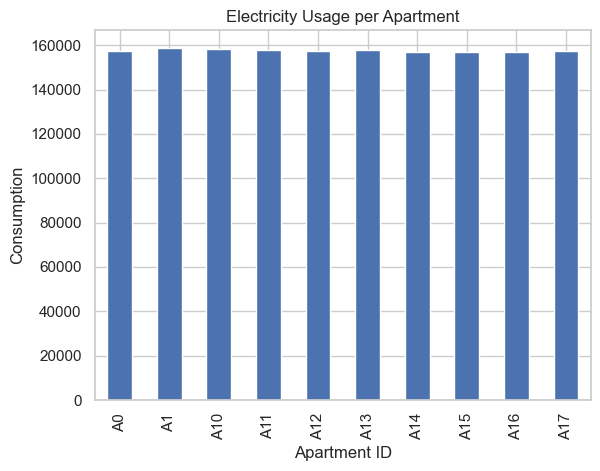

In [96]:
import matplotlib.pyplot as plt

apartment_usage.head(10).plot(kind='bar')
plt.title("Electricity Usage per Apartment")
plt.xlabel("Apartment ID")
plt.ylabel("Consumption")
plt.show()

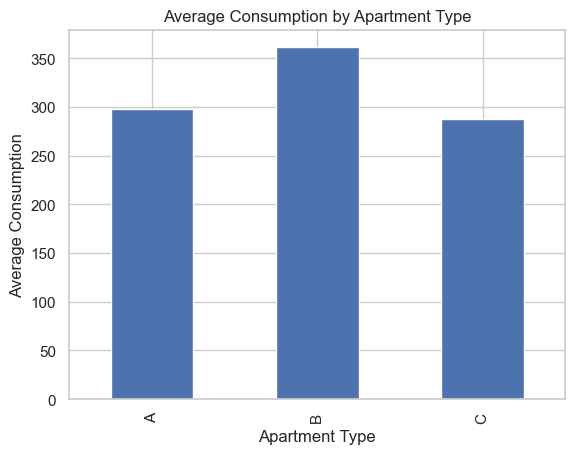

In [97]:
type_usage.plot(kind='bar')
plt.title("Average Consumption by Apartment Type")
plt.xlabel("Apartment Type")
plt.ylabel("Average Consumption")
plt.show()

In [98]:
apartment_usage.reset_index().to_csv("apartment_usage_clean.csv", index=False)
type_usage.reset_index().to_csv("type_usage_clean.csv", index=False)

In [99]:
# Save the final cleaned version for the next sprint weeks
df.to_csv('cleaned_apartment_data.csv', index=False)
print("Week 2: Cleaned dataset is ready and saved.")

Week 2: Cleaned dataset is ready and saved.


C:\Users\User\AppData\Local\Temp\ipykernel_8912\1742309992.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='apartment_type', y='electricity_consumption', data=df, palette='Set2')


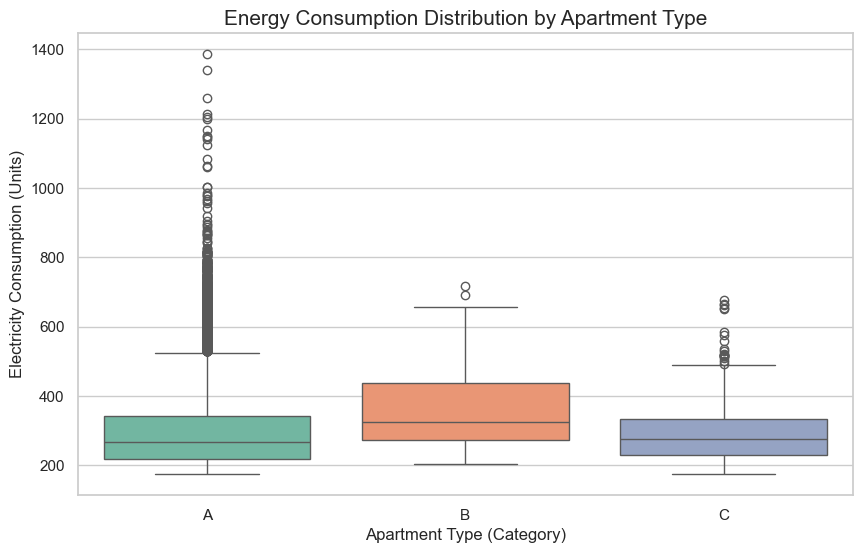

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a boxplot to compare electricity consumption by apartment type
plt.figure(figsize=(10, 6))
sns.boxplot(x='apartment_type', y='electricity_consumption', data=df, palette='Set2')

# Add professional titles and labels for your demo
plt.title('Energy Consumption Distribution by Apartment Type', fontsize=15)
plt.xlabel('Apartment Type (Category)', fontsize=12)
plt.ylabel('Electricity Consumption (Units)', fontsize=12)

# Save the chart for your website framework
plt.savefig('consumption_boxplot.png')
plt.show()

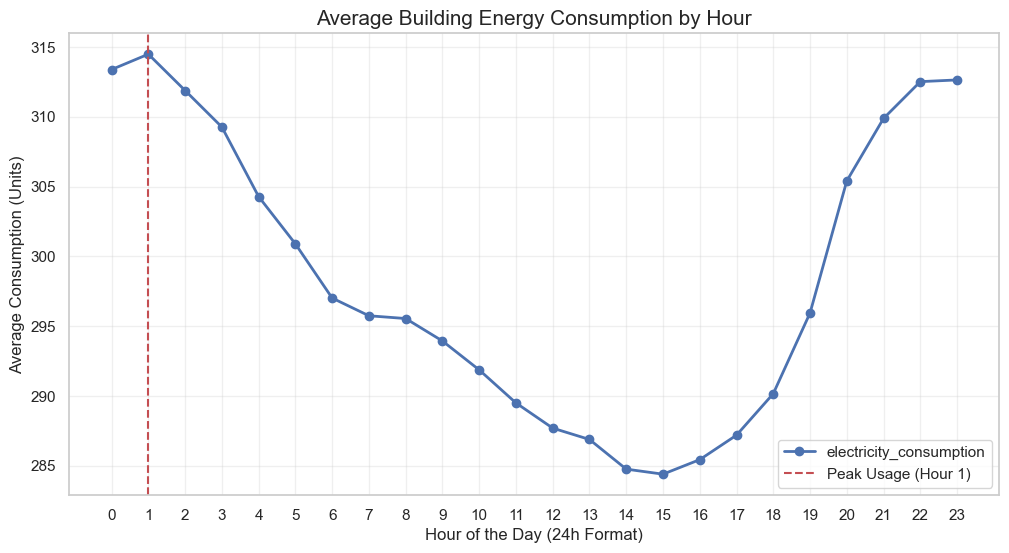

In [101]:
# Group by hour to see the building-wide trend
hourly_trend = df.groupby('hour')['electricity_consumption'].mean()

plt.figure(figsize=(12, 6))
hourly_trend.plot(kind='line', marker='o', color='b', linewidth=2)

# Highlighting the peak hour for the demo
plt.axvline(x=1, color='r', linestyle='--', label='Peak Usage (Hour 1)')

plt.title('Average Building Energy Consumption by Hour', fontsize=15)
plt.xlabel('Hour of the Day (24h Format)', fontsize=12)
plt.ylabel('Average Consumption (Units)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

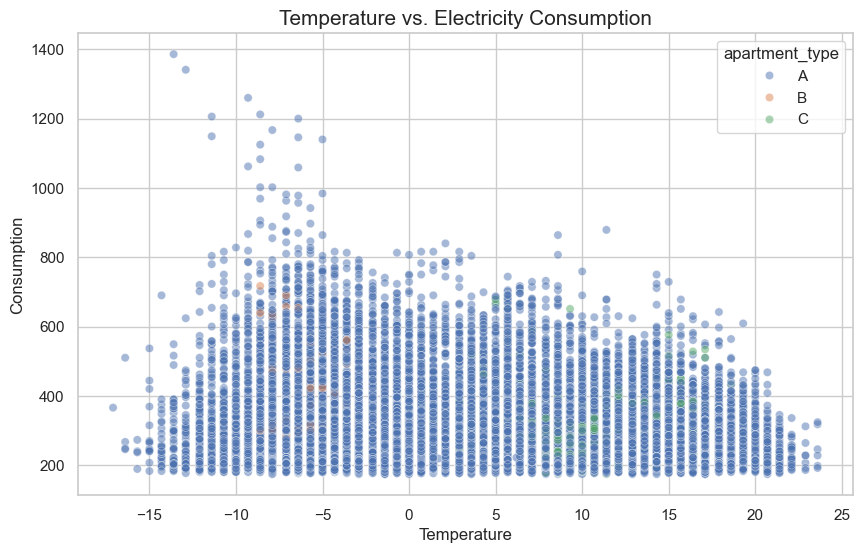

In [102]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temperature', y='electricity_consumption', hue='apartment_type', data=df, alpha=0.5)

plt.title('Temperature vs. Electricity Consumption', fontsize=15)
plt.xlabel('Temperature', fontsize=12)
plt.ylabel('Consumption', fontsize=12)
plt.show()

In [103]:
# Final Export for the Project Record
df.to_csv('final_energy_model_results.csv', index=False)
print("Project Complete: Final dataset exported.")

Project Complete: Final dataset exported.
